Dataset shape: (10000, 10)
Total rounds: 10000, Number of ads: 10

Running algorithms...
UCB - Total Reward: 2178
Thompson Sampling - Total Reward: 2613
ε-Greedy (ε=0.1) - Total Reward: 2551
ε-Greedy (ε=0.5) - Total Reward: 1935
ε-Greedy (ε=0.01) - Total Reward: 2503

Optimal ad: Ad 5 with CTR: 0.2695

COMPARISON METRICS
        Algorithm  Total Reward  Optimal Ad Selections Optimal Ad %  Average Reward  Regret
              UCB          2178                   6323       63.23%          0.2178   517.0
Thompson Sampling          2613                   9486       94.86%          0.2613    82.0
ε-Greedy (ε=0.01)          2503                   7919       79.19%          0.2503   192.0
 ε-Greedy (ε=0.1)          2551                   9057       90.57%          0.2551   144.0
 ε-Greedy (ε=0.5)          1935                   5344       53.44%          0.1935   760.0


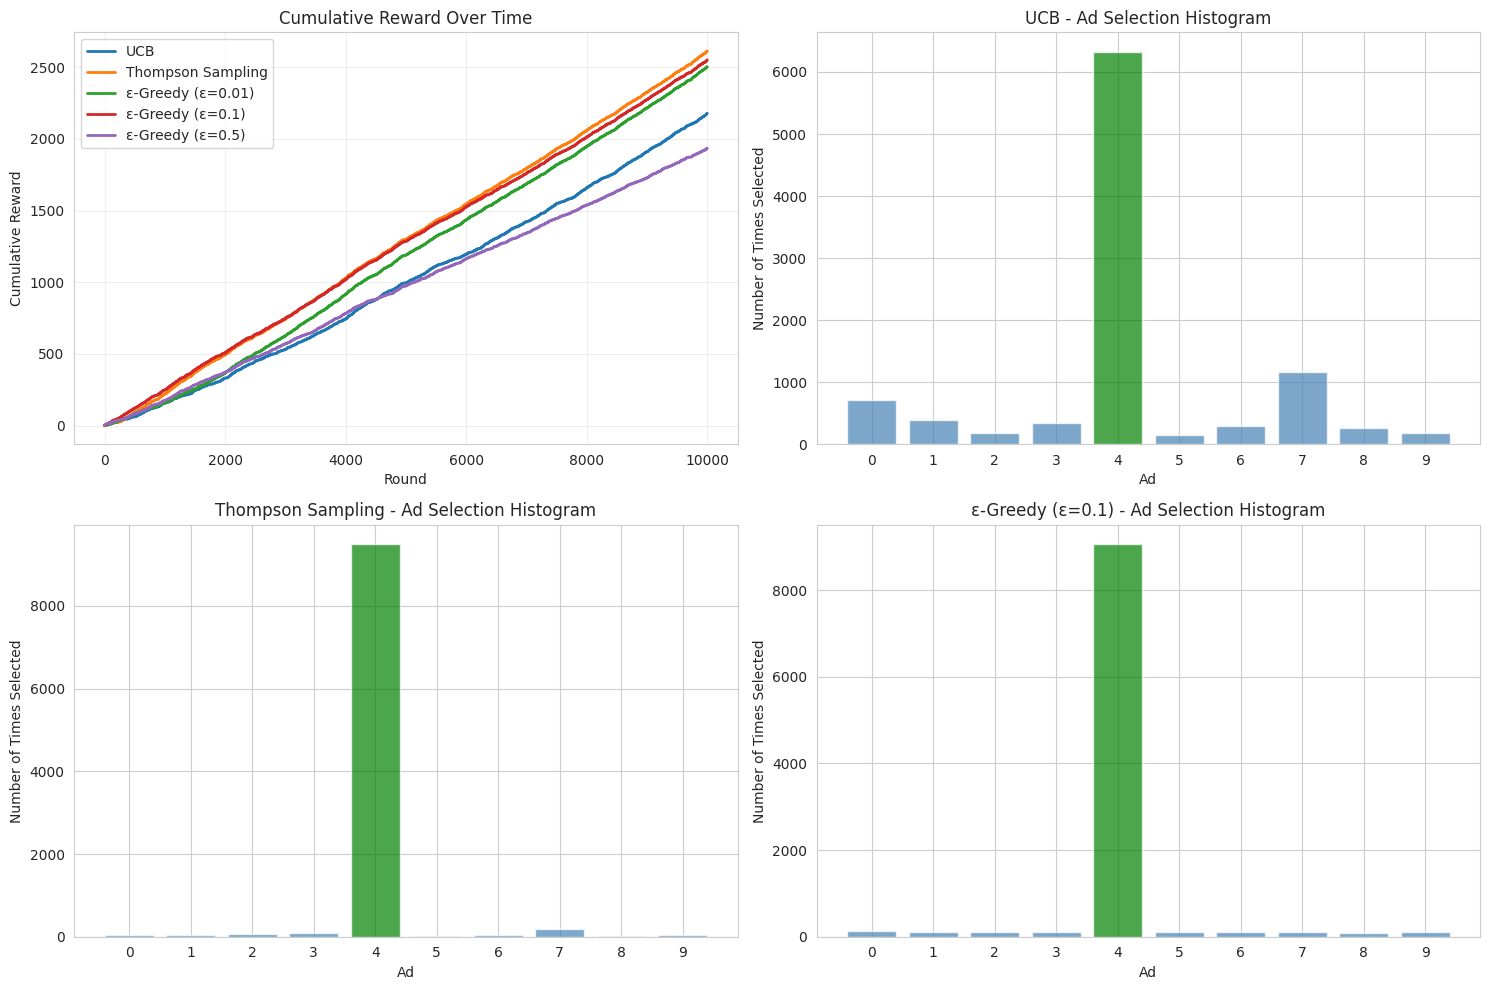

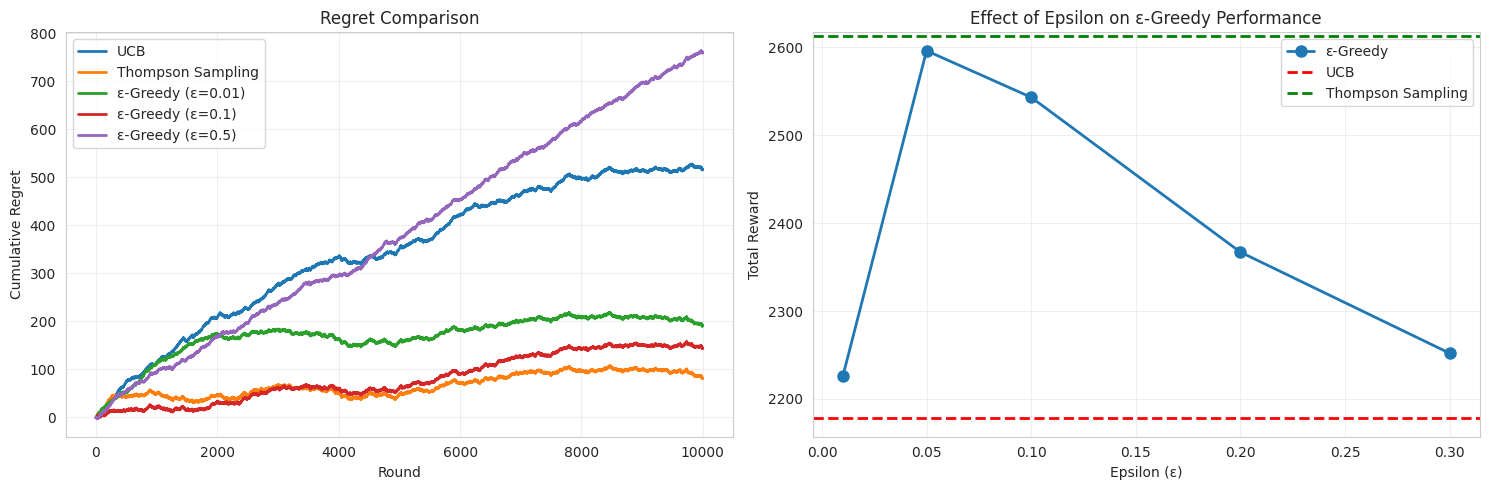

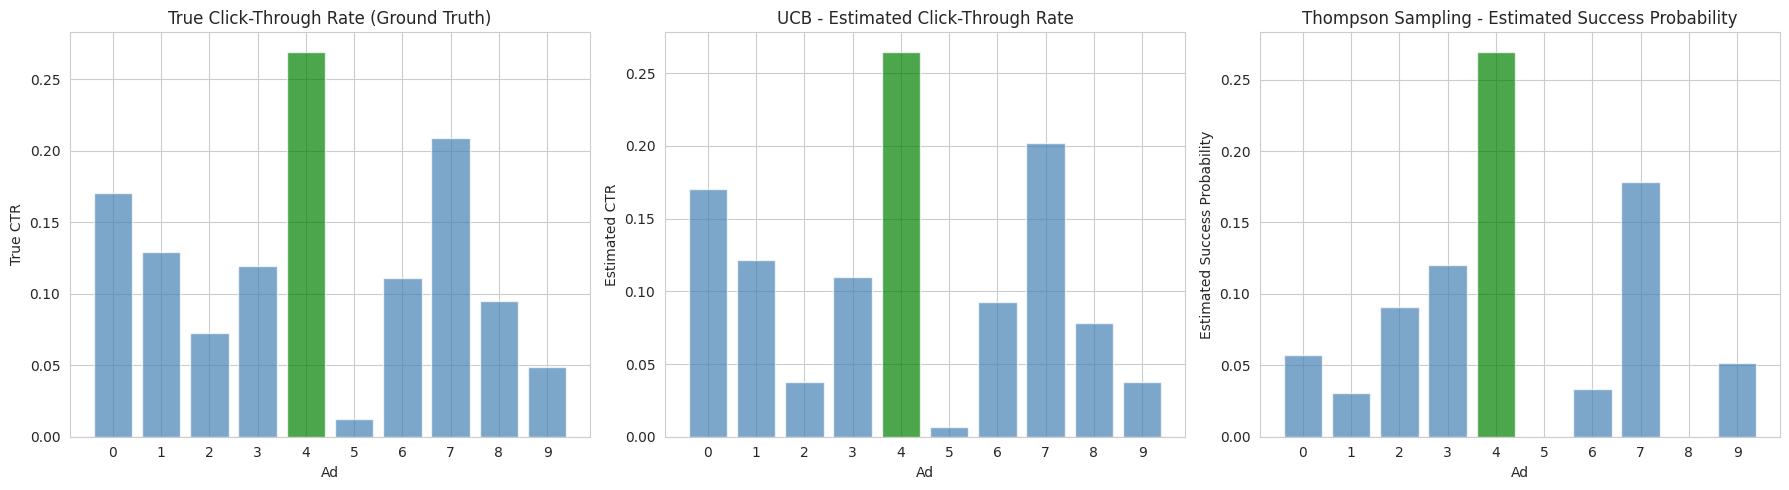


DETAILED AD SELECTION ANALYSIS
 Ad True CTR  UCB Selections  Thompson Selections  ε-Greedy (0.1) Selections
  1   0.1703             705                   35                        122
  2   0.1295             387                   33                        106
  3   0.0728             186                   55                        111
  4   0.1196             345                   83                        100
  5   0.2695            6323                 9486                       9057
  6   0.0126             150                   24                        101
  7   0.1112             292                   30                         98
  8   0.2091            1170                  191                        111
  9   0.0952             256                   24                         90
 10   0.0489             186                   39                        104

Key Findings:
✓ Optimal Ad: Ad 5 (True CTR: 0.2695)
✓ Best Algorithm: Thompson Sampling
✓ Highest Regret: ε-Greedy (ε=0.

In [2]:
# Multi-Armed Bandit Comparison: UCB vs Thompson Sampling vs ε-Greedy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Load dataset
dataset = pd.read_csv('/kaggle/input/ads-ctr/Ads_CTR_Optimisation.csv')
N_ROUNDS = 10000
N_ADS = 10

print(f"Dataset shape: {dataset.shape}")
print(f"Total rounds: {N_ROUNDS}, Number of ads: {N_ADS}")

# ============================================================================
# ALGORITHM 1: UPPER CONFIDENCE BOUND (UCB)
# ============================================================================
def ucb_algorithm(dataset, n_rounds, n_ads):
    """
    UCB Algorithm: Selects ad with highest upper confidence bound
    """
    numbers_of_selections = [0] * n_ads
    sums_of_rewards = [0] * n_ads
    ads_selected = []
    total_reward = 0
    rewards_per_round = []
    
    for n in range(n_rounds):
        ad = 0
        max_upper_bound = 0
        
        for i in range(n_ads):
            if numbers_of_selections[i] > 0:
                average_reward = sums_of_rewards[i] / numbers_of_selections[i]
                delta_i = np.sqrt(3/2 * np.log(n + 1) / numbers_of_selections[i])
                upper_bound = average_reward + delta_i
            else:
                # Unexplored arm gets high priority
                upper_bound = 1e400
            
            if upper_bound > max_upper_bound:
                max_upper_bound = upper_bound
                ad = i
        
        ads_selected.append(ad)
        numbers_of_selections[ad] += 1
        reward = dataset.values[n, ad]
        sums_of_rewards[ad] += reward
        total_reward += reward
        rewards_per_round.append(reward)
    
    return {
        'ads_selected': ads_selected,
        'total_reward': total_reward,
        'selections': numbers_of_selections,
        'sums_of_rewards': sums_of_rewards,
        'rewards_per_round': rewards_per_round
    }

# ============================================================================
# ALGORITHM 2: THOMPSON SAMPLING
# ============================================================================
# CORRECTED ALGORITHM 2: THOMPSON SAMPLING

def thompson_sampling_algorithm(dataset, n_rounds, n_ads):
    """
    Thompson Sampling: Uses Beta distribution to model arm success probabilities
    """
    numbers_of_rewards_1 = [0] * n_ads
    numbers_of_rewards_0 = [0] * n_ads
    ads_selected = []
    total_reward = 0
    rewards_per_round = []
    
    for n in range(n_rounds):
        ad = 0
        max_random = 0
        
        for i in range(n_ads):
            # Sample from Beta distribution using np.random.beta()
            random_beta = np.random.beta(
                numbers_of_rewards_1[i] + 1,
                numbers_of_rewards_0[i] + 1
            )
            
            if random_beta > max_random:
                max_random = random_beta
                ad = i
        
        ads_selected.append(ad)
        reward = dataset.values[n, ad]
        
        if reward == 1:
            numbers_of_rewards_1[ad] += 1
        else:
            numbers_of_rewards_0[ad] += 1
        
        total_reward += reward
        rewards_per_round.append(reward)
    
    return {
        'ads_selected': ads_selected,
        'total_reward': total_reward,
        'selections_1': numbers_of_rewards_1,
        'selections_0': numbers_of_rewards_0,
        'rewards_per_round': rewards_per_round
    }
# ============================================================================
# ALGORITHM 3: EPSILON-GREEDY
# ============================================================================
def epsilon_greedy_algorithm(dataset, n_rounds, n_ads, epsilon):
    """
    Epsilon-Greedy: With probability epsilon, explore randomly;
    with probability 1-epsilon, exploit the best arm so far
    """
    numbers_of_selections = [0] * n_ads
    sums_of_rewards = [0] * n_ads
    ads_selected = []
    total_reward = 0
    rewards_per_round = []
    
    for n in range(n_rounds):
        if np.random.random() < epsilon:
            # Explore: select random ad
            ad = np.random.randint(0, n_ads)
        else:
            # Exploit: select best ad so far
            if n == 0:
                ad = 0
            else:
                # Select ad with highest average reward
                average_rewards = [
                    sums_of_rewards[i] / numbers_of_selections[i]
                    if numbers_of_selections[i] > 0 else 0
                    for i in range(n_ads)
                ]
                ad = np.argmax(average_rewards)
        
        ads_selected.append(ad)
        numbers_of_selections[ad] += 1
        reward = dataset.values[n, ad]
        sums_of_rewards[ad] += reward
        total_reward += reward
        rewards_per_round.append(reward)
    
    return {
        'ads_selected': ads_selected,
        'total_reward': total_reward,
        'selections': numbers_of_selections,
        'sums_of_rewards': sums_of_rewards,
        'rewards_per_round': rewards_per_round
    }

# ============================================================================
# RUN ALL ALGORITHMS
# ============================================================================
print("\n" + "="*70)
print("Running algorithms...")
print("="*70)

# Set random seed for reproducibility
np.random.seed(42)

ucb_results = ucb_algorithm(dataset, N_ROUNDS, N_ADS)
print(f"UCB - Total Reward: {ucb_results['total_reward']}")

ts_results = thompson_sampling_algorithm(dataset, N_ROUNDS, N_ADS)
print(f"Thompson Sampling - Total Reward: {ts_results['total_reward']}")

eg_results_01 = epsilon_greedy_algorithm(dataset, N_ROUNDS, N_ADS, epsilon=0.1)
print(f"ε-Greedy (ε=0.1) - Total Reward: {eg_results_01['total_reward']}")

eg_results_05 = epsilon_greedy_algorithm(dataset, N_ROUNDS, N_ADS, epsilon=0.5)
print(f"ε-Greedy (ε=0.5) - Total Reward: {eg_results_05['total_reward']}")

eg_results_001 = epsilon_greedy_algorithm(dataset, N_ROUNDS, N_ADS, epsilon=0.01)
print(f"ε-Greedy (ε=0.01) - Total Reward: {eg_results_001['total_reward']}")

# ============================================================================
# ANALYSIS: Find optimal ad
# ============================================================================
# Calculate which ad is truly optimal in the dataset
optimal_ctr = []
for i in range(N_ADS):
    ctr = dataset.iloc[:, i].sum() / len(dataset)
    optimal_ctr.append(ctr)

optimal_ad = np.argmax(optimal_ctr)
print(f"\nOptimal ad: Ad {optimal_ad + 1} with CTR: {optimal_ctr[optimal_ad]:.4f}")

# ============================================================================
# COMPARISON METRICS
# ============================================================================
def compute_metrics(results, dataset, optimal_ad, algorithm_name):
    """Compute performance metrics for an algorithm"""
    selections = results['ads_selected']
    optimal_selections = sum(1 for ad in selections if ad == optimal_ad)
    
    return {
        'Algorithm': algorithm_name,
        'Total Reward': results['total_reward'],
        'Optimal Ad Selections': optimal_selections,
        'Optimal Ad %': f"{100 * optimal_selections / N_ROUNDS:.2f}%",
        'Average Reward': results['total_reward'] / N_ROUNDS,
        'Regret': (optimal_ctr[optimal_ad] * N_ROUNDS) - results['total_reward']
    }

metrics_list = [
    compute_metrics(ucb_results, dataset, optimal_ad, 'UCB'),
    compute_metrics(ts_results, dataset, optimal_ad, 'Thompson Sampling'),
    compute_metrics(eg_results_001, dataset, optimal_ad, 'ε-Greedy (ε=0.01)'),
    compute_metrics(eg_results_01, dataset, optimal_ad, 'ε-Greedy (ε=0.1)'),
    compute_metrics(eg_results_05, dataset, optimal_ad, 'ε-Greedy (ε=0.5)')
]

metrics_df = pd.DataFrame(metrics_list)
print("\n" + "="*70)
print("COMPARISON METRICS")
print("="*70)
print(metrics_df.to_string(index=False))

# ============================================================================
# VISUALIZATION 1: Reward Per Round (Cumulative)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Cumulative rewards
ax = axes[0, 0]
ax.plot(np.cumsum(ucb_results['rewards_per_round']), label='UCB', linewidth=2)
ax.plot(np.cumsum(ts_results['rewards_per_round']), label='Thompson Sampling', linewidth=2)
ax.plot(np.cumsum(eg_results_001['rewards_per_round']), label='ε-Greedy (ε=0.01)', linewidth=2)
ax.plot(np.cumsum(eg_results_01['rewards_per_round']), label='ε-Greedy (ε=0.1)', linewidth=2)
ax.plot(np.cumsum(eg_results_05['rewards_per_round']), label='ε-Greedy (ε=0.5)', linewidth=2)
ax.set_xlabel('Round')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Histogram: UCB selections
ax = axes[0, 1]
ucb_counts = np.bincount(ucb_results['ads_selected'], minlength=N_ADS)
colors = ['green' if i == optimal_ad else 'steelblue' for i in range(N_ADS)]
ax.bar(range(N_ADS), ucb_counts, color=colors, alpha=0.7)
ax.set_xlabel('Ad')
ax.set_ylabel('Number of Times Selected')
ax.set_title('UCB - Ad Selection Histogram')
ax.set_xticks(range(N_ADS))

# Histogram: Thompson Sampling selections
ax = axes[1, 0]
ts_counts = np.bincount(ts_results['ads_selected'], minlength=N_ADS)
colors = ['green' if i == optimal_ad else 'steelblue' for i in range(N_ADS)]
ax.bar(range(N_ADS), ts_counts, color=colors, alpha=0.7)
ax.set_xlabel('Ad')
ax.set_ylabel('Number of Times Selected')
ax.set_title('Thompson Sampling - Ad Selection Histogram')
ax.set_xticks(range(N_ADS))

# Histogram: ε-Greedy (ε=0.1) selections
ax = axes[1, 1]
eg_counts = np.bincount(eg_results_01['ads_selected'], minlength=N_ADS)
colors = ['green' if i == optimal_ad else 'steelblue' for i in range(N_ADS)]
ax.bar(range(N_ADS), eg_counts, color=colors, alpha=0.7)
ax.set_xlabel('Ad')
ax.set_ylabel('Number of Times Selected')
ax.set_title('ε-Greedy (ε=0.1) - Ad Selection Histogram')
ax.set_xticks(range(N_ADS))

plt.tight_layout()
plt.savefig('bandit_comparison_1.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 2: Regret and Exploration Behavior
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Regret comparison
ax = axes[0]
regrets = [
    np.cumsum(optimal_ctr[optimal_ad] - np.array(ucb_results['rewards_per_round'])),
    np.cumsum(optimal_ctr[optimal_ad] - np.array(ts_results['rewards_per_round'])),
    np.cumsum(optimal_ctr[optimal_ad] - np.array(eg_results_001['rewards_per_round'])),
    np.cumsum(optimal_ctr[optimal_ad] - np.array(eg_results_01['rewards_per_round'])),
    np.cumsum(optimal_ctr[optimal_ad] - np.array(eg_results_05['rewards_per_round']))
]

ax.plot(regrets[0], label='UCB', linewidth=2)
ax.plot(regrets[1], label='Thompson Sampling', linewidth=2)
ax.plot(regrets[2], label='ε-Greedy (ε=0.01)', linewidth=2)
ax.plot(regrets[3], label='ε-Greedy (ε=0.1)', linewidth=2)
ax.plot(regrets[4], label='ε-Greedy (ε=0.5)', linewidth=2)
ax.set_xlabel('Round')
ax.set_ylabel('Cumulative Regret')
ax.set_title('Regret Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Epsilon effect on final reward
ax = axes[1]
epsilon_values = [0.01, 0.05, 0.1, 0.2, 0.3]
final_rewards_eg = []
for eps in epsilon_values:
    np.random.seed(42)
    eg_res = epsilon_greedy_algorithm(dataset, N_ROUNDS, N_ADS, epsilon=eps)
    final_rewards_eg.append(eg_res['total_reward'])

ax.plot(epsilon_values, final_rewards_eg, marker='o', linewidth=2, markersize=8, label='ε-Greedy')
ax.axhline(y=ucb_results['total_reward'], color='r', linestyle='--', label='UCB', linewidth=2)
ax.axhline(y=ts_results['total_reward'], color='g', linestyle='--', label='Thompson Sampling', linewidth=2)
ax.set_xlabel('Epsilon (ε)')
ax.set_ylabel('Total Reward')
ax.set_title('Effect of Epsilon on ε-Greedy Performance')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bandit_comparison_2.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 3: Ad Performance Estimation
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True CTR
ax = axes[0]
true_ctr = [dataset.iloc[:, i].sum() / len(dataset) for i in range(N_ADS)]
colors = ['green' if i == optimal_ad else 'steelblue' for i in range(N_ADS)]
ax.bar(range(N_ADS), true_ctr, color=colors, alpha=0.7)
ax.set_xlabel('Ad')
ax.set_ylabel('True CTR')
ax.set_title('True Click-Through Rate (Ground Truth)')
ax.set_xticks(range(N_ADS))

# UCB estimated CTR
ax = axes[1]
ucb_estimated_ctr = [
    ucb_results['sums_of_rewards'][i] / ucb_results['selections'][i]
    if ucb_results['selections'][i] > 0 else 0
    for i in range(N_ADS)
]
colors = ['green' if i == optimal_ad else 'steelblue' for i in range(N_ADS)]
ax.bar(range(N_ADS), ucb_estimated_ctr, color=colors, alpha=0.7)
ax.set_xlabel('Ad')
ax.set_ylabel('Estimated CTR')
ax.set_title('UCB - Estimated Click-Through Rate')
ax.set_xticks(range(N_ADS))

# Thompson Sampling estimated success probability
ax = axes[2]
ts_estimated_prob = [
    ts_results['selections_1'][i] / (ts_results['selections_1'][i] + ts_results['selections_0'][i])
    if (ts_results['selections_1'][i] + ts_results['selections_0'][i]) > 0 else 0
    for i in range(N_ADS)
]
colors = ['green' if i == optimal_ad else 'steelblue' for i in range(N_ADS)]
ax.bar(range(N_ADS), ts_estimated_prob, color=colors, alpha=0.7)
ax.set_xlabel('Ad')
ax.set_ylabel('Estimated Success Probability')
ax.set_title('Thompson Sampling - Estimated Success Probability')
ax.set_xticks(range(N_ADS))

plt.tight_layout()
plt.savefig('bandit_comparison_3.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "="*70)
print("DETAILED AD SELECTION ANALYSIS")
print("="*70)

comparison_data = []
for i in range(N_ADS):
    comparison_data.append({
        'Ad': i + 1,
        'True CTR': f"{true_ctr[i]:.4f}",
        'UCB Selections': ucb_results['selections'][i],
        'Thompson Selections': ts_results['selections_1'][i] + ts_results['selections_0'][i],
        'ε-Greedy (0.1) Selections': np.bincount(eg_results_01['ads_selected'], minlength=N_ADS)[i]
    })

comparison_table = pd.DataFrame(comparison_data)
print(comparison_table.to_string(index=False))

print("\n" + "="*70)
print("Key Findings:")
print("="*70)
print(f"✓ Optimal Ad: Ad {optimal_ad + 1} (True CTR: {optimal_ctr[optimal_ad]:.4f})")
print(f"✓ Best Algorithm: {metrics_df.iloc[np.argmax(metrics_df['Total Reward'])]['Algorithm']}")
print(f"✓ Highest Regret: {metrics_df.iloc[np.argmax(metrics_df['Regret'])]['Algorithm']}")